# 彼图 BeTu：在 Jupyter 中绘图

先安装 `betu`，按顺序运行单元格。比较 NW、BW、NS、BS 四种模式的利润。

In [1]:
%config InlineBackend.figure_format = 'retina' # 在 Jupyter 中显示高清图片
from betu import *


彼图 BeTu 1.0.0 — Be better tool for U!
科研仿真与 Excel 数据绘图，快速上手：
  makefig()                         打开中英文图形界面
  make_example('draw_lines')         公式到曲线（单参数仿真）
  make_example('draw_max_area')      模式比较（最大值区域）
  make_example('draw_detail_area')   关系区域比较
  make_example('draw_3D')            公式到三维图
  make_example('data_lines')         根据数据绘制曲线
  make_example('plot_table')         Excel/表格数据绘图
  make_example('data_pie')           饼图；另有 data_bar、data_barh、data_box、data_hist、data_scatter、data_line
  make_example('disconnected_modes') 同一模式被分隔后逐块标注
  make_example('smart_regions')      小区域标记自动避让与引导线
以上命令打印带注释的完整代码，可复制后修改；read_table(path) 可读取 Excel/CSV。
在 Jupyter 单元格开头加入以下魔法命令，高清显示图形：
%config InlineBackend.figure_format = 'retina' # 在 Jupyter 中显示高清图片
普通 .py 脚本中不要使用上述魔法命令。



## 定义公式和固定参数

使用符号 E 表示模型参数；乘方写为 `**`。

In [2]:
# 定义符号
E, alpha, b, c_n, c_r, delta, e_n, e_r, k, p_e = symbols('E, alpha, b, c_n, c_r, delta, e_n, e_r, k, p_e')

# 表达式
expressions = {
    '$\\pi_r^{NW}$': E*p_e+(k*(alpha*delta*(c_n+e_n*p_e)-(c_r+e_r*p_e))**2)/(8*(k+alpha*delta*(1-alpha*delta))**2),
    '$\\pi_r^{BW}$': E*p_e + ( k*(delta*(c_n+e_n*p_e)-(c_r+e_r*p_e+b))**2 )/( 8*(k+delta-delta**2)**2),
    '$\\pi_r^{NS}$': E*p_e + ((k+2*alpha*delta)*(alpha*delta*(c_n+e_n*p_e)-(c_r+e_r*p_e))**2 )/( 8*(k+alpha*delta*(2-alpha*delta))**2),
    '$\\pi_r^{BS}$': E*p_e + ( (k+2*delta)*(delta*(c_n+e_n*p_e)-(c_r+e_r*p_e+b))**2 )/( 8*(k+2*delta-delta**2)**2),
}

# 参数赋值
assigns = {c_n: 0.2, c_r: 0.1, delta: 0.8, E: 2.0, e_n: 1.0, e_r: 0.6, k: 1.1, p_e: 0.1}

## 绘制关系区域图

横轴为 alpha（0.7～0.8），纵轴为 b（0～0.08）。图例放在图外，标明各区域的利润排序。

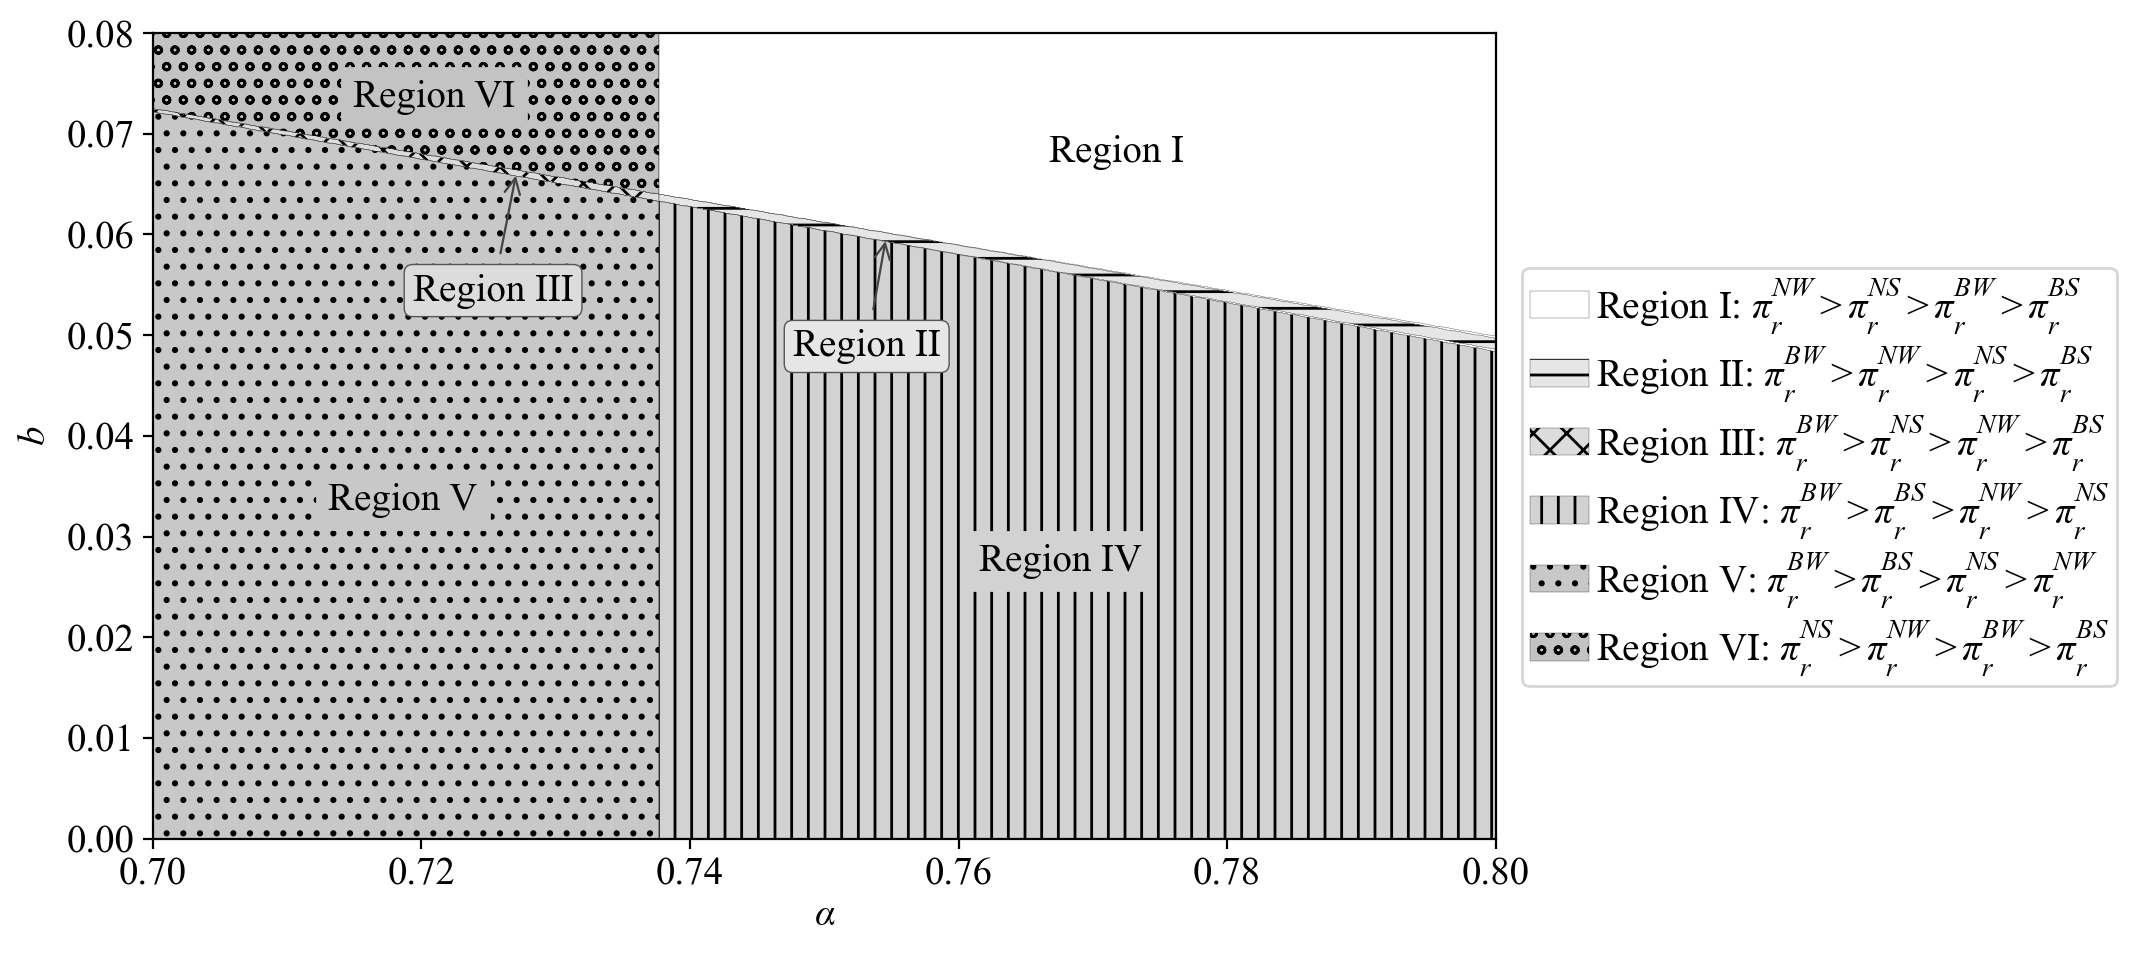

In [3]:
%config InlineBackend.figure_format = 'retina' # 在 Jupyter 中显示高清图片
pattern_moves = [[0, 0], [-0.018, -0.007], [0.004, -0.013], [0, 0], [0, 0], [0, 0]]
the_plt = draw_detail_area(
    expressions, assigns, alpha, [0.7, 0.8], b, [0, 0.08],
    x_name=r'$\alpha$', y_name='$b$', precision=1000, figsize=[8, 5],
    pattern_moves=pattern_moves,
)
the_plt.show()

## 生成带注释的完整示例

下一个单元格打印完整代码，按需复制并修改参数。其他图形可用 `make_example('draw_lines')`、`make_example('data_pie')` 等。

In [4]:
make_example('draw_detail_area')

from betu import *

# 定义符号
E, alpha, b, c_n, c_r, delta, e_n, e_r, k, p_e = symbols('E, alpha, b, c_n, c_r, delta, e_n, e_r, k, p_e')

# 表达式
expressions = {
    '$\\pi_r^{NW}$': E*p_e+(k*(alpha*delta*(c_n+e_n*p_e)-(c_r+e_r*p_e))**2)/(8*(k+alpha*delta*(1-alpha*delta))**2),
    '$\\pi_r^{BW}$': E*p_e + ( k*(delta*(c_n+e_n*p_e)-(c_r+e_r*p_e+b))**2 )/( 8*(k+delta-delta**2)**2),
    '$\\pi_r^{NS}$': E*p_e + ((k+2*alpha*delta)*(alpha*delta*(c_n+e_n*p_e)-(c_r+e_r*p_e))**2 )/( 8*(k+alpha*delta*(2-alpha*delta))**2),
    '$\\pi_r^{BS}$': E*p_e + ( (k+2*delta)*(delta*(c_n+e_n*p_e)-(c_r+e_r*p_e+b))**2 )/( 8*(k+2*delta-delta**2)**2),
}

# 参数赋值
assigns = {c_n: 0.2, c_r: 0.1, delta: 0.8, E: 2.0, e_n: 1.0, e_r: 0.6, k: 1.1, p_e: 0.1}

# 横轴分析参数
the_var_x = alpha

# 横轴参数取值范围
start_end_x = [0.7, 0.8]

# 纵轴分析参数
the_var_y = b

# 纵轴参数取值范围
start_end_y = [0, 0.08]

# x 轴名称
x_name = '$\\alpha$'

# y 轴名称
y_name = '$b$'

# 整体字号
fsize = 14

# 区域文字字号增量
text_fsize_add = -2

# 自动保存图片
save_dir = None

# 采样点数（越高越细）
pr